# 가설 3. 잠재적 불만자의 Pain Point 식별

- 저만족 및 심각 저만족 응답자의 주관식 의견에는 불만 또는 개선 요구 맥락이 포함될 것이다.

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_style("whitegrid")

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 데이터 로드

In [2]:
df = pd.read_excel("../data/master_table.xlsx")

## 1. 주관식 의견 작성 비율

### 1) 전체 응답자 중 주관식 의견 작성 여부 비율

In [3]:
text_cols = ["text_01"]

df["text_response_flag"] = \
    df[text_cols].notna().any(axis=1)

print("\n[전체 응답자 중 주관식 의견 작성 개수]")
print(df["text_response_flag"].sum())

print("\n[전체 응답자 중 주관식 의견 작성 비율]")
print(df["text_response_flag"].mean().round(3))


[전체 응답자 중 주관식 의견 작성 개수]
308

[전체 응답자 중 주관식 의견 작성 비율]
0.308


### 2) 세그먼트별 주관식 응답 작성 비율

In [4]:
# text 작성 여부 (빈문자/공백 제외)
df["text_response_flag"] = (
    df["text_01"].fillna("").astype(str).str.strip() != ""
)

# 3그룹 마스크
mask_general = (~df["low_sat_flag"]) & (~df["serious_sat_flag"])
mask_low_only = (df["low_sat_flag"]) & (~df["serious_sat_flag"])
mask_serious = (df["low_sat_flag"]) & (df["serious_sat_flag"])

def ratio_within_group(mask, label):
    group = df[mask]
    ratio = group["text_response_flag"].mean()
    print(f"[{label}] n={len(group)}, wrote={group['text_response_flag'].sum()} → 비율={ratio:.3f}")

ratio_within_group(mask_general, "일반 응답자(저만족 아님)")
ratio_within_group(mask_low_only, "저만족(심각 제외)")
ratio_within_group(mask_serious, "심각 저만족")

[일반 응답자(저만족 아님)] n=623, wrote=164 → 비율=0.263
[저만족(심각 제외)] n=257, wrote=79 → 비율=0.307
[심각 저만족] n=120, wrote=65 → 비율=0.542


## 2. 주관식 의견 내 요구 / 불만 표현 비율

- 주관식 의견 내 요구 및 불만 표현 비율은 다음 방식으로 산출하였다.
(자동 분류와 수동 검토를 병행)
    - 1차적으로 키워드 기반 자동 분류를 통해 긍정/부정을 구분하고 컬럼으로 구조화하였다.
    - 2차적으로 애매한 표현은 사람이 직접 검토 및 재분류하였다.

### 1) 세그먼트별 주관식 의견 내 요구 / 불만 표현 비율

| 구분            | 주관식 의견 수 | 요청 / 불만 응답 수 | 비율         |
| ------------- | -------- | ------------ | ---------- |
| 일반 응답자        | 164      | 82           | **50.00%** |
| 잠재적 불만자 (저만족) | 79       | 62           | **78.48%** |
| 심각한 저만족 응답자   | 65       | 62           | **95.38%** |


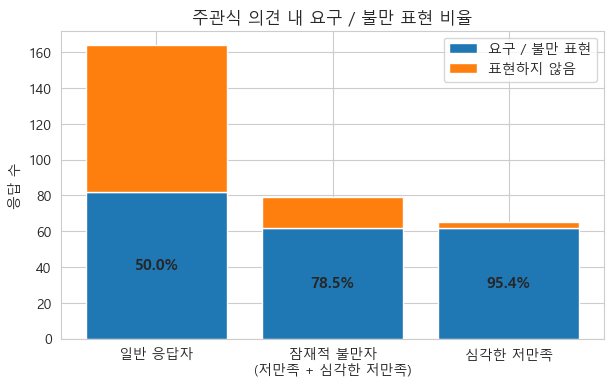

In [8]:
groups = [
    '일반 응답자',
    '잠재적 불만자\n(저만족 + 심각한 저만족)',
    '심각한 저만족'
]

# 요구 / 불만 표현
expressed = np.array([82, 62, 62])

# 표현하지 않음
not_expressed = np.array([82, 17, 3])

totals = expressed + not_expressed
pct = (expressed / totals * 100).round(1)

plt.figure(figsize=(7,4))

bars1 = plt.bar(groups, expressed, label='요구 / 불만 표현')
bars2 = plt.bar(groups, not_expressed, bottom=expressed, label='표현하지 않음')

# 퍼센트 표시
for bar, p in zip(bars1, pct):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() / 2,
        f'{p}%',
        ha='center',
        va='center',
        fontsize=11,
        weight='bold'
    )

plt.ylabel('응답 수')
plt.title('주관식 의견 내 요구 / 불만 표현 비율')
plt.legend()

plt.show()

## 3. 결론

분석 결과, 만족도 수준에 따라 주관식 의견 작성 행동과 내용 특성에서 뚜렷한 차이가 관찰되었다.

먼저, 주관식 의견 작성 비율은 다음과 같이 나타났다.

- 일반 응답자(저만족 아님): **26.3%**
- 저만족 응답자(심각 제외): **30.7%**
- 심각 저만족 응답자: **54.2%**

이는 만족도가 낮을수록 의견을 서술형으로 표출하려는 경향이 강화됨을 보여준다.

또한 주관식 의견 내용 분석 결과, 단순 참여 여부를 넘어 **의견 표출의 성격 자체에서도 차이가 확인되었다.**

| 구분 | 주관식 의견 수 | 요청 / 불만 응답 수 | 비율 |
|-------------|-------------|------------------|-------------|
| 일반 응답자 | 164 | 82 | **50.00%** |
| 잠재적 불만자 (저만족) | 79 | 62 | **78.48%** |
| 심각한 저만족 응답자 | 65 | 62 | **95.38%** |

일반 응답자의 경우 요청/불만 성격의 의견 비율이 50% 수준에 머문 반면, 저만족 응답자에서는 78.48%, 심각 저만족 응답자에서는 95.38%로 급격히 증가하였다.

이는 만족도가 낮을수록 주관식 응답 참여율뿐 아니라, **의견 표출 강도 역시 증가하는 경향**을 보임을 시사한다.  
즉, 만족도 하락은 단순 점수 변화가 아니라 **불만, 문제 인식, 개선 요구로 이어지는 행동 신호로 작동**하고 있음을 의미한다.

따라서 가설 3 —  

> **“저만족 및 심각 저만족 응답자의 주관식 의견에는 불만 또는 개선 요구 맥락이 포함될 것이다.”**

는 데이터 분석 결과 지지되었다.